In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [3]:
df = pd.read_csv('./2025_Airbnb_NYC_listings.csv')
df.shape

(22308, 73)

### 데이터 확인

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22308 non-null  int64  
 1   id                                            22308 non-null  int64  
 2   source                                        22308 non-null  str    
 3   name                                          22308 non-null  str    
 4   description                                   21903 non-null  str    
 5   neighborhood_overview                         12262 non-null  str    
 6   host_id                                       22308 non-null  int64  
 7   host_name                                     22288 non-null  str    
 8   host_since                                    22288 non-null  str    
 9   host_location                                 17025 non-null  str    
 1

### 결측치 확인 및 처리
- 결측치가 어떤 컬럼에 있는가?
- 가짜 결측치는 없는가?
- 결측치를 가진 컬럼에서 결측치 비율은 어떻게 되는가?
- 각 결측치 drop 기준은 어떻게 정할까?
- 결측치를 drop할까? or 컬럼을 날릴까?

In [11]:
#가짜 결측치 리스트 만들기
fake_null = ['NaN', 'None', 'none', 'NULL', 'null', 'N/A', 'na', '']
#가짜 결측치 개수 확인
df.isin(fake_null).sum()    # ---- 결과는 없었음
#가격이 중요하다! 가격 관련 컬럼들의 결측치 비율 확인 = 결측치 없음
(df[['price', 'minimum_nights','maximum_nights','availability_365','instant_bookable']].isna().sum() / len(df['price'])) * 100

price              0.00
minimum_nights     0.00
maximum_nights     0.00
availability_365   0.00
instant_bookable   0.00
dtype: float64

In [12]:
#모든 컬럼의 결측치 비율 확인 (정렬)
((df.isna().sum() / len(df)) * 100).sort_values(ascending=False)

calendar_updated                               100.00
license                                         79.99
neighbourhood                                   45.03
neighborhood_overview                           45.03
host_about                                      39.97
                                                ...  
instant_bookable                                 0.00
calculated_host_listings_count                   0.00
calculated_host_listings_count_entire_homes      0.00
calculated_host_listings_count_private_rooms     0.00
calculated_host_listings_count_shared_rooms      0.00
Length: 73, dtype: float64

In [20]:
#모든 컬럼들 중 결측치 비율이 너무 높거나, 낮은 컬럼 확인 
#                   -------- > 0% ~ 2% / 70% 이상 
#                                    결측치를 drop(2%이하?) | 컬럼을 delete(70%이상?) 할 컬럼 후보
missing_ratio = (df.isna().sum() / len(df)) * 100        

lower_mask = (missing_ratio > 0) & (missing_ratio <= 2)
higher_mask = missing_ratio >= 70

filtered_hilo = missing_ratio[lower_mask | higher_mask]
filtered_hilo.sort_values(ascending=False)

#70% 이상 결측치가 있는 컬럼 정보 : calender_updated, license >> 주요 컬럼표에 없음
#0%~2% 사이 컬럼 정보 : 호스트 관련 8개, 숙소 정보 5개 컬럼, 기타 컬럼 1개(has_availability : 예약 가능 여부)
#host_name, host_since, host_location, host_about, host_response_time, host_response_rate, host_acceptance_rate, host_is_superhost  

calendar_updated            100.00
license                      79.99
description                   1.82
host_is_superhost             1.68
has_availability              1.10
beds                          0.35
bedrooms                      0.22
host_name                     0.09
host_has_profile_pic          0.09
host_verifications            0.09
host_total_listings_count     0.09
host_listings_count           0.09
host_since                    0.09
host_identity_verified        0.09
bathrooms_text                0.06
bathrooms                     0.03
dtype: float64

In [24]:
#결측치가 2%보다 높고, 70%보다 낮은 컬럼 정보
filtered_median = missing_ratio[(missing_ratio > 2) & (missing_ratio < 70)]
filtered_median.sort_values(ascending=False)

neighborhood_overview         45.03
neighbourhood                 45.03
host_about                    39.97
review_scores_location        30.48
review_scores_checkin         30.47
first_review                  30.47
review_scores_accuracy        30.47
review_scores_cleanliness     30.47
review_scores_rating          30.47
last_review                   30.47
review_scores_value           30.47
review_scores_communication   30.47
reviews_per_month             30.47
host_location                 23.68
host_neighbourhood            21.20
host_response_time            19.69
host_response_rate            19.69
host_acceptance_rate          15.54
dtype: float64

In [25]:
x_reviews = df['review_scores_rating'].isnull().sum()
print(f"리뷰 점수가 없는 숙소: {x_reviews}개")

리뷰 점수가 없는 숙소: 6798개


### 컬럼 확인 
- 필요없는 컬럼은 어떤게 있을까?
- 데이터 타입으로 나누기 & 4가지 형태 중 어떤 형태일까?
- 가격과 상관 없는 컬럼 분류해보기

In [14]:
df.dtypes.value_counts()            #문자형이 30개, 숫자형 43개...

str        30
float64    23
int64      20
Name: count, dtype: int64

### 컬럼 정보 표 만들기

In [17]:
#기본 식별 / 데이터 수집정보 관련 컬럼 4개
cols_meta = df[['Unnamed: 0','id','source', 'calendar_last_scraped']]
#숙소 기본 정보 컬럼 11개
cols_listing = df[['name', 'description', 'neighborhood_overview', 'property_type', 'room_type', 'accommodates', 'bathrooms','bathrooms_text', 'bedrooms', 'beds', 'amenities']]
#위치 정보 컬럼 5개
cols_location = df[['neighbourhood','neighbourhood_group_cleansed', 'neighbourhood_cleansed', 'latitude', 'longitude']]
#호스트 정보 컬럼 15개
cols_host = df[['host_id', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost','host_neighbourhood', 'host_listings_count', 'host_total_listings_count','host_verifications','host_has_profile_pic','host_identity_verified',]]
#가격 및 예약 정책 컬럼 16개
cols_booking = df[['price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy', 'instant_bookable']]
#리뷰 및 수요 정보 컬럼 16개
cols_review_demand = df[['number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month','estimated_occupancy_l365d', 'estimated_revenue_l365d']]
#기타 컬럼 5개
cols_misc = df[['license', 'calendar_updated', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']]

In [19]:
#이건 보기쉽게 LLM 사용해서 나눠준 것
sections = {
    "기본 식별 / 데이터 수집정보": cols_meta,
    "숙소 기본 정보": cols_listing,
    "위치 정보": cols_location,
    "호스트 정보": cols_host,
    "가격 및 예약 정책": cols_booking,
    "리뷰 및 수요 정보": cols_review_demand,
    "기타": cols_misc
}

for name, data in sections.items():
    print(f"📌 {name}")
    print(f"컬럼 개수: {data.shape[1]}")
    print(f"shape: {data.shape}")
    print("-" * 40)

📌 기본 식별 / 데이터 수집정보
컬럼 개수: 4
shape: (22308, 4)
----------------------------------------
📌 숙소 기본 정보
컬럼 개수: 11
shape: (22308, 11)
----------------------------------------
📌 위치 정보
컬럼 개수: 5
shape: (22308, 5)
----------------------------------------
📌 호스트 정보
컬럼 개수: 15
shape: (22308, 15)
----------------------------------------
📌 가격 및 예약 정책
컬럼 개수: 16
shape: (22308, 16)
----------------------------------------
📌 리뷰 및 수요 정보
컬럼 개수: 16
shape: (22308, 16)
----------------------------------------
📌 기타
컬럼 개수: 6
shape: (22308, 6)
----------------------------------------


### Dtype 변환

In [26]:
# str 컬럼안에 date type이 숨어있다! datetime으로 변환
date_cols = ['host_since', 'first_review', 'last_review' , 'calendar_last_scraped']

df[date_cols] = df[date_cols].apply(pd.to_datetime,errors='coerce')

df[date_cols].dtypes

host_since               datetime64[us]
first_review             datetime64[us]
last_review              datetime64[us]
calendar_last_scraped    datetime64[us]
dtype: object

In [29]:
# price 타입 str -> float 으로 변환
df['price']=(df['price'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False).astype(float))
df['price'].dtype

#중앙값, 평균값에 비해 최대값이 너무 크다는 것을 알 수 있음. 이상치 존재 가능성
df['price'].describe()     

# price 로그변환
df["price_log1p"] = np.log1p(df["price"])  # log(1+Fare)
df["price_log1p"]

0       5.30
1       4.42
2       6.64
3       4.94
4       4.88
        ... 
22303   4.29
22304   4.08
22305   5.70
22306   5.30
22307   4.08
Name: price_log1p, Length: 22308, dtype: float64

In [30]:
#1박 숙박비 고가 상품 분포 확인
print("500달러 이상:", len(df[df["price"] >= 500]) / len(df['price']) * 100)        #가격이 500달러 이상인 숙소는 전체의 6% 정도
print("1000달러 이상:", len(df[df["price"] >= 1000]) / len(df['price']) * 100)      #가격이 1000달러 이상인 숙소는 전체의 1.5% 정도
print("2000달러 이상:", len(df[df["price"] >= 2000]) / len(df['price']) * 100)      #가격이 2000달러 이상인 숙소는 전체의 0.4% 정도
print("5000달러 이상:", len(df[df["price"] >= 5000]) / len(df['price']) * 100)      #가격이 5000달러 이상인 숙소는 전체의 0.09% 정도
print("10000달러 이상:", len(df[df["price"] >= 10000]) / len(df['price']) * 100)    #가격이 10000달러 이상인 숙소는 전체의 0.04% 정도
print("전체 숙소 수:", len(df['price']))

500달러 이상: 5.899228976152053
1000달러 이상: 1.4434283665052896
2000달러 이상: 0.38999462076385155
5000달러 이상: 0.08517123901739286
10000달러 이상: 0.04930966469428008
전체 숙소 수: 22308


### 컬럼 확인

### 범주형 변수의 모델링을 위한 인코딩 
- (문자형 변수 -> 숫자형 변수로 바꿔주기)
- df.dtypes.value_counts()            #문자형이 30개, 숫자형 43개였다.
- 어떤게 범주형 변수일까?

In [34]:
#범주형 변수의 유니크값 개수 확인
str_cols = df.select_dtypes(include='object').columns
unique_counts = df[str_cols].nunique()
unique_counts

C:\Users\lch\AppData\Local\Temp\ipykernel_25096\1805199286.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns


source                              1
name                            21342
description                     17854
neighborhood_overview            8232
host_name                        5343
host_location                     421
host_about                       5804
host_response_time                  4
host_response_rate                 65
host_acceptance_rate               96
host_is_superhost                   2
host_neighbourhood                446
host_verifications                  6
host_has_profile_pic                2
host_identity_verified              2
neighbourhood                       1
neighbourhood_cleansed            221
neighbourhood_group_cleansed        5
property_type                      57
room_type                           4
bathrooms_text                     31
amenities                       18410
has_availability                    1
license                          1894
instant_bookable                    2
dtype: int64

In [35]:
#unique 값이 2~4개인 컬럼 -----------> 사실상 얘네들만 인코딩 하면 되지않나?
low_cardinality = unique_counts[unique_counts.between(2,4)]
low_cardinality.sort_values(ascending=False)

host_response_time        4
room_type                 4
host_is_superhost         2
host_has_profile_pic      2
host_identity_verified    2
instant_bookable          2
dtype: int64

In [36]:
#unique 값이 7개 이상인 컬럼
high_cardinality = unique_counts[unique_counts >= 7]
high_cardinality.sort_values(ascending=False)

name                      21342
amenities                 18410
description               17854
neighborhood_overview      8232
host_about                 5804
host_name                  5343
license                    1894
host_neighbourhood          446
host_location               421
neighbourhood_cleansed      221
host_acceptance_rate         96
host_response_rate           65
property_type                57
bathrooms_text               31
dtype: int64

### 매핑 필요한 것?

In [96]:
property_map = {
    'Room in hotel': 'Lodging',
    'Room in boutique hotel': 'Lodging',

    'Entire rental unit': 'Residential',
    'Private room in rental unit': 'Residential',
    'Private room in home': 'Residential',
    'Entire home': 'Residential',
    'Entire condo': 'Residential',
    'Private room in townhouse': 'Residential',
    'Private room in condo': 'Residential',
    'Entire townhouse': 'Residential',
    'Entire loft': 'Residential',
    'Entire guest suite': 'Residential'
}

df['property_regulation_type'] = df['property_type'].map(property_map)
df['property_regulation_type'] = df['property_regulation_type'].fillna('Other')
df['property_regulation_type'].value_counts()
#Residential : 주거형
#Lodging : 숙박형

property_regulation_type
Residential    20335
Lodging         1026
Other            947
Name: count, dtype: int64

In [39]:
#대여 방식에 따른 분류
def rental_strategy(row):
    
    # 1. 호텔형 (숙박업)
    if row['property_regulation_type'] == 'Lodging':
        return 'hotel'
    
    # 2. 주거형 + 30박 이상
    elif row['minimum_nights'] >= 30:
        return 'residential_mid'
    
    # 3. 주거형 + 30박 미만
    else:
        return 'residential_short'


df['rental_strategy'] = df.apply(rental_strategy, axis=1)
df['rental_strategy'].value_counts()

rental_strategy
residential_mid      17830
residential_short     3452
hotel                 1026
Name: count, dtype: int64

In [40]:
df.groupby('rental_strategy')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
rental_strategy,,,,,,,,
hotel,1026.00,478.49,1151.01,8.00,177.00,265.00,511.25,20000.00
residential_mid,17830.00,197.13,368.10,10.00,78.00,130.00,225.00,15200.00
residential_short,3452.00,221.45,256.98,7.00,105.00,162.00,246.25,5000.00


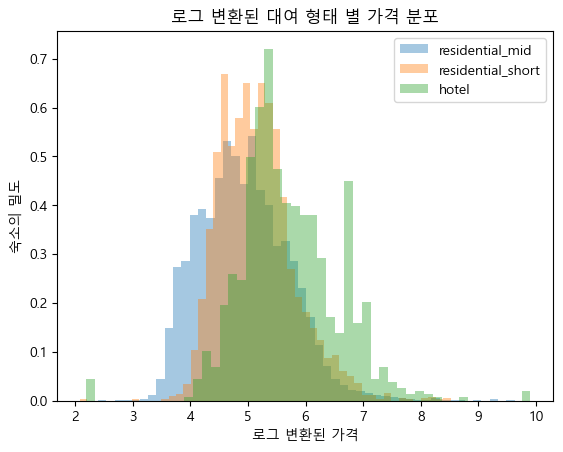

In [41]:
for strategy in df['rental_strategy'].unique():
    subset = df[df['rental_strategy'] == strategy]
    plt.hist(subset['price_log1p'], bins=50, alpha=0.4, label=strategy, density=True)

plt.legend()
plt.xlabel('로그 변환된 가격')
plt.ylabel('숙소의 밀도')
plt.title('로그 변환된 대여 형태 별 가격 분포')
plt.show()

# 오른쪽으로 갈수록 가격이 높고,
# 막대가 높을수록 해당 가격대에 속한 숙소 개수가 많다. 
# density=True 옵션으로 인해, 막대의 높이는 해당 가격대에 속한 숙소의 밀도를 나타냄. 
# 즉, 가격이 특정 범위에 몰려있을수록 막대가 높아짐.

In [42]:
#연간 매출 추정을 보자. (그룹별 = rental_strategy)
df['estimated_revenue_l365d'].isna().sum()
#연간 매출 추정 분포 확인
df['estimated_revenue_l365d'].describe() #----- 0값이 있다 -> 추정 매출이 없다?

count     22308.00
mean      11901.94
std       24186.92
min           0.00
25%           0.00
50%           0.00
75%       16500.00
max     1020050.00
Name: estimated_revenue_l365d, dtype: float64

In [44]:
(df['estimated_revenue_l365d'] == 0).mean()    #약 54% 정도의 숙소가 연간 추정 매출이 0에 수렴

np.float64(0.5484131253362022)

In [ ]:
#각 대여 형태 별로 연간 매출이 0인 숙소의 비율
for strategy in df['rental_strategy'].unique():
    subset = df[df['rental_strategy'] == strategy]
    zero_ratio = (subset['estimated_revenue_l365d'] == 0).mean()
    print(strategy, zero_ratio)
# residential_mid   64%
# hotel             51%
# residential_short 7%

### !추정 매출이 어떻게 계산되는걸까?

In [43]:
#예약과 추정매출의 관계를 알아보자
#1년 내내 예약 불가능한 숙소들의 Top 10 매출은 얼마인가? >> 예약이 불가능한데도 매출은 나온다? >> 다른 플랫폼에서 장사하는듯 (airbnb에서 예약 불가)
df['estimated_revenue_l365d'][df['availability_365'] == 0].sort_values(ascending=False).head(10)

15282   114750.00
15281    99450.00
12504    70380.00
14926    68760.00
7100     60720.00
3547     52020.00
17827    45645.00
8122     45135.00
9055     41565.00
14851    36960.00
Name: estimated_revenue_l365d, dtype: float64

In [45]:
#리뷰와 추정매출의 관계를 알아보자
df[df['estimated_revenue_l365d'] == 0]['number_of_reviews'].describe()

count   12234.00
mean       16.16
std        43.84
min         0.00
25%         0.00
50%         0.00
75%         9.00
max       644.00
Name: number_of_reviews, dtype: float64

In [46]:
#추정 매출 0이면서 리뷰도 0인 숙소의 비율 약 55%
(df[df['estimated_revenue_l365d'] == 0]['number_of_reviews'] == 0).mean()

np.float64(0.5556645414418833)

In [47]:
#최근 12개월의 리뷰도 확인 -> 매출이 0인 숙소들의 최근 12개월 리뷰 수는 전부 0이다?... 장사를 안하는 건가
df[df['estimated_revenue_l365d'] == 0]['number_of_reviews_ltm'].describe()

count   12234.00
mean        0.00
std         0.00
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         0.00
Name: number_of_reviews_ltm, dtype: float64

In [49]:
#추정 매출 0이면서 최근 12개월 리뷰가 0인것들의 비율은 100%
zero_ltm_zero_ratio = (df[df['estimated_revenue_l365d'] == 0]['number_of_reviews_ltm'] == 0).mean()
(df[df['estimated_revenue_l365d'] == 0]['number_of_reviews_ltm'] == 0).mean()

#airbnb에서는 최근 12개월 리뷰 수로 매출을 추정하는듯?

np.float64(1.0)

In [82]:
df['amenities'].dtypes

<StringDtype(storage='python', na_value=nan)>

In [94]:
df['calendar_updated'].isna().sum()

np.int64(22308)

In [84]:
df['amenities'].duplicated().sum()

np.int64(3898)